###Train Classification Models

In [ ]:
#Handle class imbalance with SMOTE + RandomUnderSampler
over = SMOTE(sampling_strategy=0.1,random_state=42) #Increase fraud to 10% of majority
under = RandomUnderSampler(sampling_strategy=0.2,random_state=42) #final ratio 1:5

X_resampled,y_resampled = over.fit_resample(X_train_scaled,y_train)
X_resampled,y_resampled = under.fit_resample(X_resampled,y_resampled)

In [ ]:
#Logistic Regression (iterpretable baseline)
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_resampled,y_resampled)
models['logistic_regression'] = lr_model

In [ ]:
#LightGBM (faster gradient boosting)
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    class_weight='balanced',
    verbose=-1
)

lgb_model.fit(X_resampled,y_resampled)
models['lightgbm'] = lgb_model

In [ ]:
#XGboost (robust gradient boosting)
scale_pos_weight= (y_resampled == 0).sum() / (y_resampled==1).sum()

xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb_model.fit(X_resampled,y_resampled)
models['xgboost'] = xgb_model

###Evaluate models

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
#Evaluating model performances with fintech-relevant metrics
results={}

for model_name, model in models.items():
  if model_name == 'isolation_forest':
    continue

  y_pred_proba = model.predict_proba(X_test)[:,1]
  y_pred = (y_pred_proba >= 0.5).astype(int)

  auc_score = roc_auc_score(y_test,y_pred_proba)
  precision,recall,_ = precision_recall_curve(y_test,y_pred_proba)
  # Sort precision and recall values to ensure correct order for AUC calculation
  sorted_indices = np.argsort(recall)
  precision = precision[sorted_indices]
  recall = recall[sorted_indices]
  pr_auc = auc(recall,precision)
  avg_precision = average_precision_score(y_test,y_pred_proba)

  report = classification_report(y_test,y_pred,output_dict=True)

  results[model_name] = {
      'auc_roc': auc_score,
      'auc_pr': pr_auc,
      'avg_precision': avg_precision,
      'precision_fraud': report['1']['precision'],
      'recall_fraud': report['1']['recall'],
      'f1_fraud': report['1']['f1-score'],
      'precision_legit': report['0']['precision'],
      'recall_legit': report['0']['recall'],
      'predictions': y_pred
  }

  print(f"AUC-ROC: {auc_score:.4f}")
  print(f"PR-AUC: {pr_auc:.4f}")
  print(f"Avg Precision: {avg_precision:.4f}")
  print(f"Fraud Precision: {report['1']['precision']:.4f}")
  print(f"Fraud Recall: {report['1']['recall']:.4f}")
  print(f"Fraud F1: {report['1']['f1-score']:.4f}")

AUC-ROC: 0.5070
PR-AUC: 0.0058
Avg Precision: 0.0020
Fraud Precision: 0.0000
Fraud Recall: 0.0000
Fraud F1: 0.0000
AUC-ROC: 0.9739
PR-AUC: 0.7202
Avg Precision: 0.7195
Fraud Precision: 0.4725
Fraud Recall: 0.8776
Fraud F1: 0.6143
AUC-ROC: 0.9689
PR-AUC: 0.7500
Avg Precision: 0.7491
Fraud Precision: 0.3452
Fraud Recall: 0.8878
Fraud F1: 0.4971


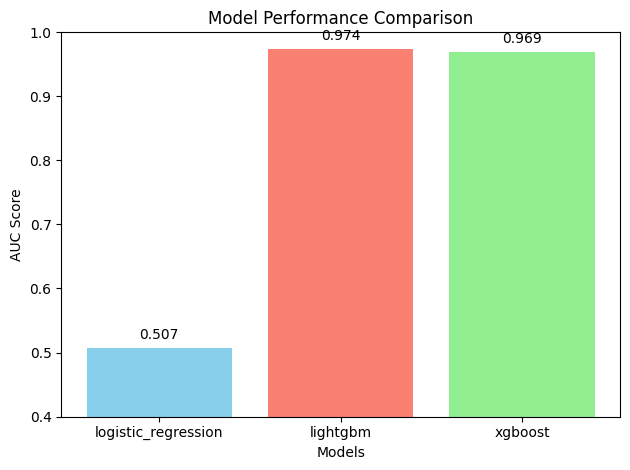

In [ ]:
#Comparing model performances based on AUC Score
model_names = list(results.keys())
auc_scores = [results[name]['auc_roc'] for name in model_names]

colors = ['skyblue','salmon','lightgreen']
bars = plt.bar(model_names,auc_scores,color=colors[:len(model_names)])
plt.xlabel('Models')
plt.ylabel('AUC Score')
plt.title('Model Performance Comparison')
plt.ylim(0.4,1.0)
for bar, score in zip(bars, auc_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

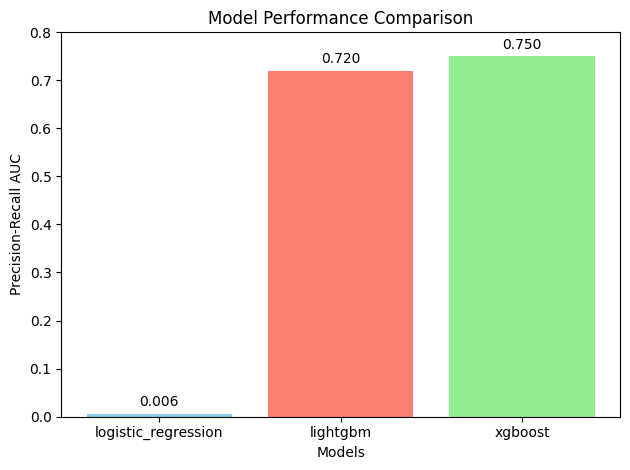

In [ ]:
#Comparing model performances based on PR-AUC
model_names = list(results.keys())
pr_aucs = [results[name]['auc_pr'] for name in model_names]

colors = ['skyblue','salmon','lightgreen']
bars = plt.bar(model_names,pr_aucs,color=colors[:len(model_names)])
plt.xlabel('Models')
plt.ylabel('Precision-Recall AUC')
plt.title('Model Performance Comparison')
plt.ylim(0.0,0.8)
for bar, score in zip(bars, pr_aucs):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
#Best model based on AUC-ROC
best_model_name= max(results.keys(),key=lambda x: results[x]['auc_roc'])
print(f"Best Model: {best_model_name.upper()} AUC-ROC: {results[best_model_name]['auc_roc']:.4f}")

Best Model: LIGHTGBM AUC-ROC: 0.9739


In [ ]:
#Best model based on Precision-Recall AUC
best_model_name= max(results.keys(),key=lambda x: results[x]['auc_pr'])
print(f"Best Model: {best_model_name.upper()} AUC-PR: {results[best_model_name]['auc_pr']:.4f}")

Best Model: XGBOOST AUC-PR: 0.7500


In [ ]:
evaluation_results = results
best_model_name = best_model_name

####Why consider PR-AUC instead of normal AUC score?
**What exactly is Precision-Recall AUC?** *focuses specifically on the performance of the model on the positive class(fraud) and highlights the trade-off between precision and recall*

**Why choose PR-AUC?** *much more realistic picture of a model's performance in catching fraud while minimizing false alarms*

Most fraud datasets are **highly imbalanced**.

Thus, evaluating the model's performance based on only a **single metric**(i.e. AUC score) can be misleading - why? because, *it evaluates a model's ability to ditinguish between positive and negative classes across all classification thresholds*.

A good model for fraud detection will have both **high precision**(minimizes false alarms;improves operational efficiency) and **high recall**(maximizes fraud caught;minimizes financial losses).

In the context of Fraud Detection,
cost of **FN(fraud transaction missed)** > cost of **FP(legit transaction flagged as fraud)**

